In [2]:
import torch

In [3]:
from sklearn.datasets import make_moons

total_samples = 1000
random_seed = 42

X,y = make_moons(n_samples = total_samples, noise = 0.07, random_state = random_seed)

X[:10] , y[:10]

(array([[-0.03341062,  0.4213911 ],
        [ 0.99882703, -0.4428903 ],
        [ 0.88959204, -0.32784256],
        [ 0.34195829, -0.41768975],
        [-0.83853099,  0.53237483],
        [ 0.59906425, -0.28977331],
        [ 0.29009023, -0.2046885 ],
        [-0.03826868,  0.45942924],
        [ 1.61377123, -0.2939697 ],
        [ 0.693337  ,  0.82781911]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

In [4]:
import pandas as pd
data_df = pd.DataFrame({"X0":X[:,0] , "X1":X[:,1] , "y":y})

data_df.head()

,X0,X1,y
0,-0.033411,0.421391,1
1,0.998827,-0.442890,1
2,0.889592,-0.327843,1
3,0.341958,-0.417690,1
4,-0.838531,0.532375,0


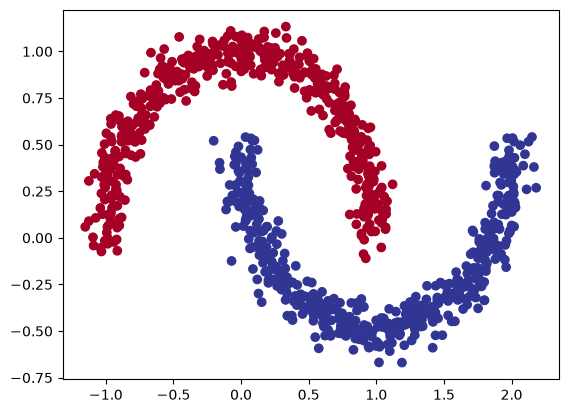

In [5]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0] , X[:,1], c=y, cmap = plt.cm.RdYlBu)

In [6]:
import numpy as np
X = torch.from_numpy(
    data_df[["X0", "X1"]].to_numpy(dtype=np.float32)
).type(torch.float)

y = torch.from_numpy(
    data_df["y"].to_numpy(dtype=np.float32)
).type(torch.float)

In [7]:
X[:5] , y[:5]

(tensor([[-0.0334,  0.4214],
         [ 0.9988, -0.4429],
         [ 0.8896, -0.3278],
         [ 0.3420, -0.4177],
         [-0.8385,  0.5324]]),
 tensor([1., 1., 1., 1., 0.]))

In [8]:
from sklearn.model_selection import train_test_split
X_train , X_test ,  y_train , y_test = train_test_split(X , y , train_size = 0.8 , random_state = random_seed)

len(X_train) , len(X_test) ,  len(y_train) , len(y_test)

(800, 200, 800, 200)

In [9]:
from torch import nn

class MoonModel_0(nn.Module):
    def __init__(self , in_features , out_features , hidden_units):
        super().__init__()
        self.layer1 = nn.Linear(in_features = in_features , out_features = hidden_units)
        self.layer2 = nn.Linear(in_features = hidden_units , out_features = hidden_units)
        self.layer3 = nn.Linear(in_features = hidden_units , out_features = out_features)
        self.ReLU = nn.ReLU()

    def forward(self , x):
        return self.layer3(self.ReLU(self.layer2(self.ReLU(self.layer1(x)))))

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_0 = MoonModel_0(in_features = 2 , out_features = 1 , hidden_units = 10).to(device)
model_0

MoonModel_0(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (ReLU): ReLU()
)

In [11]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.4357, -0.1213],
                      [ 0.4432, -0.2126],
                      [ 0.5867, -0.1537],
                      [-0.1120,  0.2205],
                      [-0.3604, -0.3158],
                      [ 0.7027, -0.3254],
                      [-0.5103, -0.6264],
                      [-0.7030, -0.6946],
                      [-0.3147,  0.4264],
                      [-0.6838,  0.2108]])),
             ('layer1.bias',
              tensor([ 0.3320, -0.4774, -0.1828,  0.5956, -0.0888, -0.4040, -0.5668, -0.3815,
                      -0.0203, -0.5993])),
             ('layer2.weight',
              tensor([[-0.0781, -0.2029, -0.0117,  0.0868, -0.0792, -0.0621,  0.1288, -0.0838,
                       -0.1229,  0.1090],
                      [ 0.0224,  0.1435, -0.1422,  0.2718,  0.2963, -0.3096,  0.2342,  0.1181,
                       -0.1574, -0.3091],
                      [ 0.0265,  0.1054,  0.1024, -0.1123,  0.2559,  0.0320

In [12]:
X.shape , y.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [13]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_0.parameters() , lr = 0.1)

In [14]:
print(f"logits: {model_0(X_train.to(device)[:10]).squeeze()}")

logits: tensor([0.1999, 0.1884, 0.2151, 0.2163, 0.2284, 0.2114, 0.2284, 0.2236, 0.2427,
        0.1886], grad_fn=<SqueezeBackward0>)


In [15]:
print(f"pred_probs: {torch.sigmoid(model_0(X_train.to(device)[:10]).squeeze())}")

pred_probs: tensor([0.5498, 0.5470, 0.5536, 0.5539, 0.5568, 0.5527, 0.5569, 0.5557, 0.5604,
        0.5470], grad_fn=<SigmoidBackward0>)


In [16]:
print(f"Pred_labels: {torch.round(torch.sigmoid(model_0(X_train.to(device)[:10].squeeze())))}")

Pred_labels: tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<RoundBackward0>)


In [17]:
!pip -q install torchmetrics

In [18]:
from torchmetrics import Accuracy
acc_fn = Accuracy(task="multiclass" , num_classes = 2).to(device)
acc_fn

MulticlassAccuracy()

In [25]:
model_0.eval()

with torch.inference_mode():
    train_logits = model_0(X_train).squeeze()
    train_probs = torch.sigmoid(train_logits)
    train_preds = torch.round(train_probs)

print("Unique predictions:", torch.unique(train_preds))
print("Prediction counts:", torch.bincount(train_preds.long()))

Unique predictions: tensor([0., 1.])
Prediction counts: tensor([398, 402])


In [26]:
print("Train accuracy:", acc_fn(train_preds, y_train.int()))

Train accuracy: tensor(0.9975)


In [19]:
torch.manual_seed(random_seed)
epochs = 1000

X_train , Y_train = X_train.to(device) , y_train.to(device)
X_test , Y_test = X_test.to(device) , y_test.to(device)

for epoch in range (epochs):
    model_0.train()

    y_logits = model_0(X_train).to(device).squeeze()
    y_pred_probs = torch.sigmoid(y_logits)
    y_pred = torch.round(y_pred_probs)

    loss = loss_fn(y_logits , y_train)
    acc = acc_fn(y_pred , y_train.int())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()
    
    with torch.inference_mode():
        test_logits = model_0(X_test).to(device).squeeze()
        test_pred_probs = torch.sigmoid(test_logits)
        test_pred = torch.round(test_pred_probs)

    test_loss = loss_fn(test_logits , y_test)
    test_acc = acc_fn(test_pred , y_test.int())

    if epoch%100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.2f} Acc: {acc:.2f} | Test loss: {test_loss:.2f} Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 0.70 Acc: 0.50 | Test loss: 0.70 Test acc: 0.50
Epoch: 100 | Loss: 0.44 Acc: 0.80 | Test loss: 0.46 Test acc: 0.76
Epoch: 200 | Loss: 0.28 Acc: 0.87 | Test loss: 0.28 Test acc: 0.86
Epoch: 300 | Loss: 0.22 Acc: 0.89 | Test loss: 0.22 Test acc: 0.92
Epoch: 400 | Loss: 0.19 Acc: 0.92 | Test loss: 0.18 Test acc: 0.93
Epoch: 500 | Loss: 0.15 Acc: 0.94 | Test loss: 0.14 Test acc: 0.94
Epoch: 600 | Loss: 0.11 Acc: 0.96 | Test loss: 0.10 Test acc: 0.98
Epoch: 700 | Loss: 0.07 Acc: 0.98 | Test loss: 0.07 Test acc: 0.99
Epoch: 800 | Loss: 0.05 Acc: 0.99 | Test loss: 0.04 Test acc: 1.00
Epoch: 900 | Loss: 0.03 Acc: 0.99 | Test loss: 0.03 Test acc: 1.00


In [28]:
def plot_decision_boundary(model, X, y):

    # Put model and data on CPU
    model.to("cpu")
    X = X.to("cpu")
    y = y.to("cpu")

    # Create grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 101),
        np.linspace(y_min, y_max, 101)
    )

    # Convert grid into input features
    X_to_pred_on = torch.from_numpy(
        np.column_stack((xx.ravel(), yy.ravel()))
    ).float()

    # Make predictions
    model.eval()

    with torch.inference_mode():
        y_logits = model(X_to_pred_on).squeeze()

        y_pred = torch.round(torch.sigmoid(y_logits))

    # Reshape predictions
    y_pred = y_pred.reshape(xx.shape).numpy()

    # Plot decision regions
    plt.contourf(
        xx,
        yy,
        y_pred,
        cmap=plt.cm.RdYlBu,
        alpha=0.7
    )

    # Plot actual data
    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        s=40,
        cmap=plt.cm.RdYlBu
    )

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

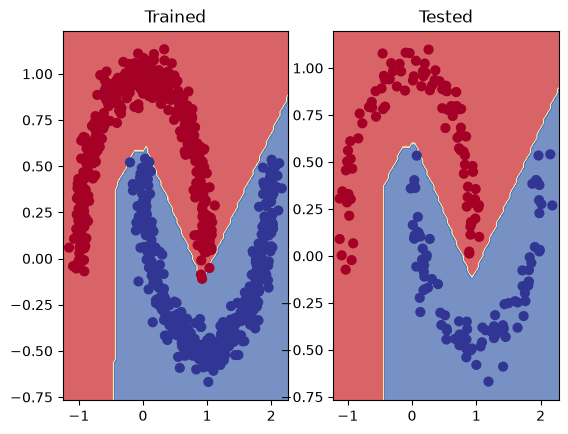

In [21]:
plt.Figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Trained")
plot_decision_boundary(model_0 , X_train , Y_train)

plt.Figure(figsize = (12,6))
plt.subplot(1,2,2)
plt.title("Tested")
plot_decision_boundary(model_0 , X_test , Y_test)

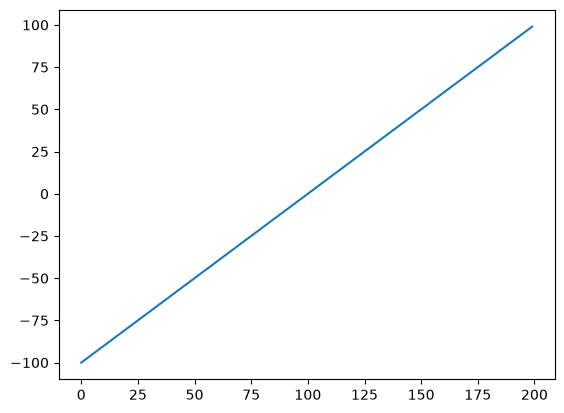

In [22]:
tensor_A = torch.arange(-100,100,1)
plt.plot(tensor_A)

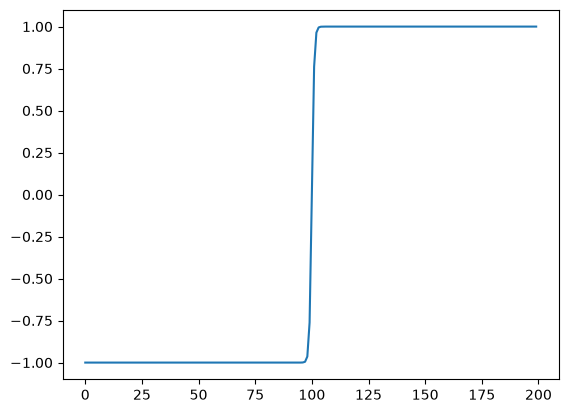

In [23]:
plt.plot(torch.tanh(tensor_A))

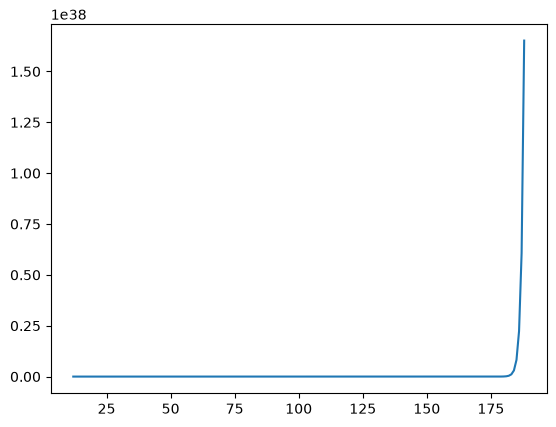

In [24]:
def tanh(x):
    return (torch.exp(x) - torch.exp(-x) / (torch.exp(x) + torch.exp(-x)))

plt.plot(tanh(tensor_A))